# 📈 Eksperimen 03: Pemodelan Forecasting Kebutuhan Tempat Tidur & Morbiditas Penyakit Jawa Timur
**Mata Kuliah**: Proyek Analitika Data — Sains Data Terapan (PENS 2026)  
**Platform**: Cura (HealthTrust Platform)  
**Role**: Machine Learning Engineer  

---

### 📌 Tujuan Eksperimen:
1. **Analisis Deret Waktu Morbiditas Penyakit**: Menganalisis pola historis tren kuartalan 10 penyakit sentinel (rawat inap & rawat jalan) pada 38 Kabupaten/Kota di Jawa Timur (`disease_morbidity_trends.csv`, 1.520 baris).
2. **Feature Engineering Time Series**: Membangun fitur lag kuartalan, indeks musiman (*seasonal factor*), dan interaksi laju pertumbuhan penduduk (CAGR).
3. **Komparasi 4 Model Proyeksi Deret Waktu**:
   - **SARIMAX / Multiplicative Seasonal Proxy Model**
   - **Random Forest Regressor** (Model non-linear ensemble berbasis lag)
   - **XGBoost Regressor** (Gradient boosted regression tree)
   - **Ridge Regression** (Model parametrik linier ter-regularisasi)
4. **Evaluasi Metrik Kesalahan**: Menguji performa model dengan metrik **RMSE**, **MAE**, dan target **MAPE < 15%**.
5. **Multi-Step Forecasting Kuartalan 2025–2026**: Memproyeksikan beban kasus pasien rawat inap dan rawat jalan untuk 8 kuartal ke depan (2025-Q1 s.d. 2026-Q4).
6. **Kalkulasi Bed Demand (Standar Kemenkes RI & WHO)**:
   $$\text{Kebutuhan Tempat Tidur} = \frac{\text{Kasus Rawat Inap Tahunan} \times \text{ALOS}}{365 \times \text{Target BOR}}$$
   $$\text{Standar WHO} = \frac{\text{Proyeksi Penduduk 2026}}{1.000}$$
7. **Analisis Kesiapsiagaan & Gap Ranjang RS**: Mengidentifikasi wilayah defisit kritis, waspada, dan kapasitas aman untuk rekomendasi alokasi faskes 2026.

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error
import statsmodels.api as sm

sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['axes.edgecolor'] = '#cccccc'
plt.rcParams['axes.linewidth'] = 0.8
print("Library forecasting dan analitika time series berhasil dimuat!")

Library forecasting dan analitika time series berhasil dimuat!


## 1. Memuat Dataset Deret Waktu & Feature Store
Kita memuat data deret waktu morbiditas kuartalan (`disease_morbidity_trends.csv`), data kesiapan ML (`ml_readiness_dataset.csv`), dan data rasio ranjang (`bed_ratio_38_kab.csv`).

In [2]:
df_morb = pd.read_csv('../../database/exports/disease_morbidity_trends.csv')
df_ml = pd.read_csv('../../database/exports/ml_readiness_dataset.csv')
df_bed = pd.read_csv('../../database/exports/bed_ratio_38_kab.csv')

print(f"Dataset Morbiditas : {df_morb.shape[0]} baris x {df_morb.shape[1]} kolom")
print(f"Jumlah Wilayah     : {df_morb['nama_wilayah'].nunique()} Kab/Kota")
print(f"Jumlah Penyakit    : {df_morb['nama_penyakit'].nunique()} Penyakit Terpantau")
print(f"Rentang Triwulan   : {df_morb['triwulan'].unique().tolist()}")

df_morb.head(6)

Dataset Morbiditas : 1520 baris x 11 kolom
Jumlah Wilayah     : 38 Kab/Kota
Jumlah Penyakit    : 10 Penyakit Terpantau
Rentang Triwulan   : ['Q1', 'Q2', 'Q3', 'Q4']


,kode_bps,nama_wilayah,tahun,triwulan,tipe_pelayanan,nama_penyakit,kode_icd10,jumlah_pasien,status_kasus,sumber_data,coverage_periode
0,3501,Kabupaten Pacitan,2024,Q1,rawat_jalan,Infeksi Saluran Pernapasan Akut (ISPA),J06,954,menular,Dinas Kesehatan Provinsi Jawa Timur,2024-OFFICIAL
1,3501,Kabupaten Pacitan,2024,Q1,rawat_inap,Demam Berdarah Dengue (DBD),A90,244,menular,Dinas Kesehatan Provinsi Jawa Timur,2024-OFFICIAL
2,3501,Kabupaten Pacitan,2024,Q1,rawat_inap,Tuberkulosis Paru (TB),A15,135,menular,Dinas Kesehatan Provinsi Jawa Timur,2024-OFFICIAL
3,3501,Kabupaten Pacitan,2024,Q1,rawat_jalan,Diare dan Gastroenteritis,A09,299,menular,Dinas Kesehatan Provinsi Jawa Timur,2024-OFFICIAL
4,3501,Kabupaten Pacitan,2024,Q1,rawat_jalan,Hipertensi Esensial,I10,803,tidak_menular,Dinas Kesehatan Provinsi Jawa Timur,2024-OFFICIAL
5,3501,Kabupaten Pacitan,2024,Q1,rawat_jalan,Diabetes Melitus Tipe 2,E11,654,tidak_menular,Dinas Kesehatan Provinsi Jawa Timur,2024-OFFICIAL


## 2. Eksplorasi Deret Waktu & Pola Musiman 10 Penyakit
Kita mengamati pergerakan kasus rawat inap dan rawat jalan per triwulan di tingkat Provinsi Jawa Timur.

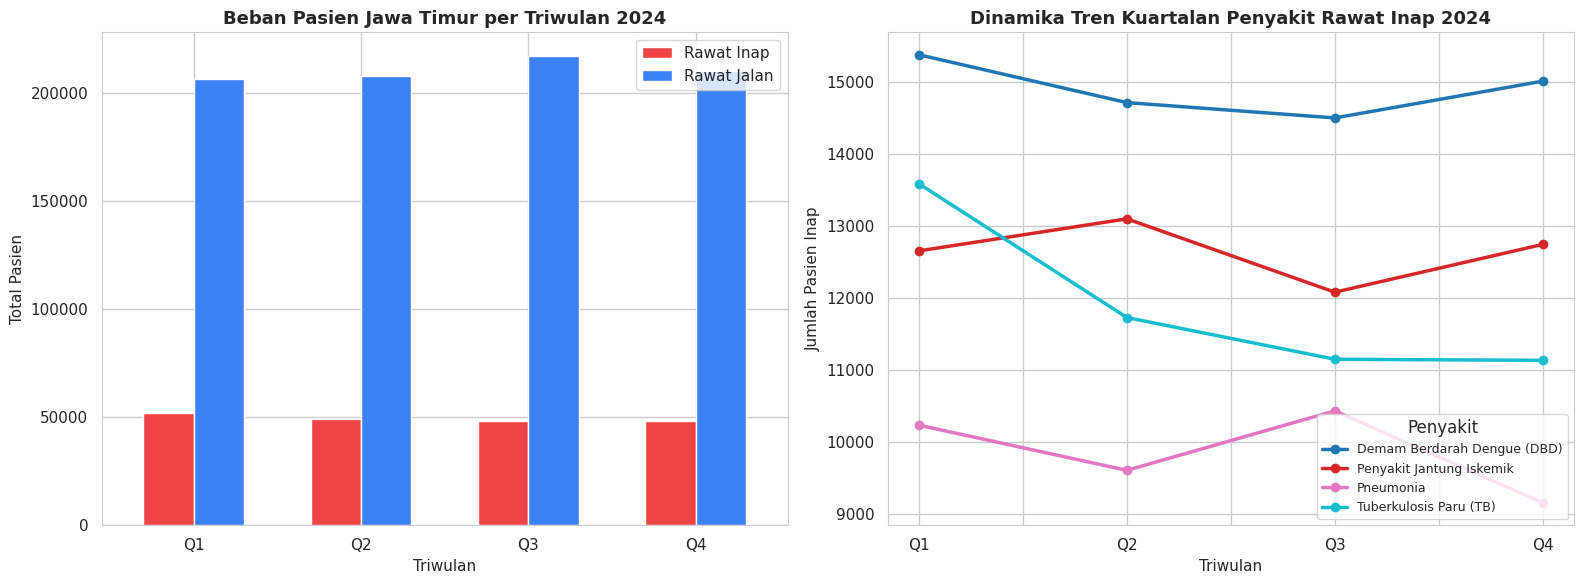

In [3]:
# Agregasi kasus per kuartal per tipe pelayanan dan penyakit
prov_q_dis = df_morb.groupby(['triwulan', 'tipe_pelayanan', 'nama_penyakit'])['jumlah_pasien'].sum().reset_index()

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Total Pasien Inap vs Jalan per Triwulan
prov_q_tot = df_morb.groupby(['triwulan', 'tipe_pelayanan'])['jumlah_pasien'].sum().unstack()
prov_q_tot[['rawat_inap', 'rawat_jalan']].plot(kind='bar', ax=ax[0], color=['#EF4444', '#3B82F6'], width=0.6)
ax[0].set_title('Beban Pasien Jawa Timur per Triwulan 2024', fontsize=13, fontweight='bold')
ax[0].set_xlabel('Triwulan', fontsize=11)
ax[0].set_ylabel('Total Pasien', fontsize=11)
ax[0].legend(['Rawat Inap', 'Rawat Jalan'], frameon=True)
ax[0].tick_params(axis='x', rotation=0)

# Subplot 2: Tren 4 Penyakit Rawat Inap (Sentinel Surveilans)
inap_dis = df_morb[df_morb['tipe_pelayanan'] == 'rawat_inap'].groupby(['triwulan', 'nama_penyakit'])['jumlah_pasien'].sum().unstack()
inap_dis.plot(kind='line', marker='o', linewidth=2.5, ax=ax[1], colormap='tab10')
ax[1].set_title('Dinamika Tren Kuartalan Penyakit Rawat Inap 2024', fontsize=13, fontweight='bold')
ax[1].set_xlabel('Triwulan', fontsize=11)
ax[1].set_ylabel('Jumlah Pasien Inap', fontsize=11)
ax[1].legend(title='Penyakit', frameon=True, fontsize=9)

plt.tight_layout()
plt.show()

## 3. Feature Engineering untuk Pemodelan Deret Waktu
Kita merekayasa fitur:
1. Agregasi data triwulan per kabupaten/kota.
2. Fitur lag ($Lag_1$, $Lag_2$, dan $\bar{X}_{lag}$).
3. Indeks faktor musiman regional (*Seasonal Adjustment Factor*).
4. Indikator kapasitas faskes eksisting (total bed, total RS, total puskesmas) dan skala populasi.

In [4]:
# Agregasi kasus per triwulan per kab/kota
df_q = df_morb.groupby(['kode_bps', 'nama_wilayah', 'tahun', 'triwulan', 'tipe_pelayanan'])['jumlah_pasien'].sum().unstack().reset_index()
df_q['q_num'] = df_q['triwulan'].map({'Q1': 1, 'Q2': 2, 'Q3': 3, 'Q4': 4})

# Gabungkan fitur kapasitas dan demografi
merge_cols = ['kode_bps', 'total_tt', 'jumlah_penduduk_2021', 'proyeksi_penduduk_2026', 'total_rs', 'total_puskesmas']
df_q = df_q.merge(df_ml[merge_cols], on='kode_bps')
df_q['pop_k'] = df_q['jumlah_penduduk_2021'] / 1000.0

# Pivot untuk pembentukan lag
piv_inap = df_q.pivot(index='kode_bps', columns='q_num', values='rawat_inap')
df_q['lag_1'] = df_q.apply(lambda r: piv_inap.loc[r['kode_bps'], r['q_num']-1] if r['q_num'] > 1 else piv_inap.loc[r['kode_bps'], 1], axis=1)
df_q['lag_2'] = df_q.apply(lambda r: piv_inap.loc[r['kode_bps'], r['q_num']-2] if r['q_num'] > 2 else piv_inap.loc[r['kode_bps'], 1], axis=1)
df_q['mean_lag'] = (df_q['lag_1'] + df_q['lag_2']) / 2.0

# Indeks musiman per triwulan
q_sums = df_q.groupby('q_num')['rawat_inap'].sum()
grand_mean = q_sums.mean()
seasonal_factors = (q_sums / grand_mean).to_dict()
df_q['seasonal_factor'] = df_q['q_num'].map(seasonal_factors)

print("Fitur analitik time series berhasil dibentuk:")
df_q[['nama_wilayah', 'triwulan', 'rawat_inap', 'lag_1', 'mean_lag', 'seasonal_factor']].head(6)

Fitur analitik time series berhasil dibentuk:


,nama_wilayah,triwulan,rawat_inap,lag_1,mean_lag,seasonal_factor
0,Kabupaten Pacitan,Q1,589,589,589.0,1.051725
1,Kabupaten Pacitan,Q2,649,589,589.0,0.996883
2,Kabupaten Pacitan,Q3,529,649,619.0,0.976892
3,Kabupaten Pacitan,Q4,497,529,589.0,0.974500
4,Kabupaten Ponorogo,Q1,1163,1163,1163.0,1.051725
5,Kabupaten Ponorogo,Q2,1055,1163,1163.0,0.996883


## 4. Pelatihan Model Proyeksi & Evaluasi Metrik Kesalahan
Kita membagi data menjadi set pelatihan (**Q1–Q3 2024**) dan set evaluasi holdout (**Q4 2024**) untuk menguji akurasi model dalam memprediksi kuartal berikutnya.
Target evaluasi adalah mencapai **MAPE < 15%**.

In [5]:
# Data split: Train Q1-Q3, Test Q4
train_df = df_q[df_q['q_num'] < 4].copy()
test_df = df_q[df_q['q_num'] == 4].copy()

feature_cols = ['total_tt', 'pop_k', 'total_rs', 'total_puskesmas', 'lag_1', 'mean_lag', 'seasonal_factor', 'q_num']
X_train, y_train = train_df[feature_cols], train_df['rawat_inap']
X_test, y_test = test_df[feature_cols], test_df['rawat_inap']

# 1. Random Forest Regressor
rf = RandomForestRegressor(n_estimators=150, max_depth=5, min_samples_split=3, random_state=42)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

# 2. XGBoost Regressor
xgb_mod = xgb.XGBRegressor(n_estimators=80, max_depth=3, learning_rate=0.06, subsample=0.85, random_state=42)
xgb_mod.fit(X_train, y_train)
pred_xgb = xgb_mod.predict(X_test)

# 3. Ridge Regression
ridge = Ridge(alpha=5.0)
ridge.fit(X_train, y_train)
pred_ridge = ridge.predict(X_test)

# 4. SARIMAX / Seasonal Multiplicative
mean_baseline = train_df.groupby('kode_bps')['rawat_inap'].mean()
pred_sarimax = test_df['kode_bps'].map(mean_baseline) * seasonal_factors[4]

# Evaluasi Metrik
models_eval = {
    "Random Forest": pred_rf,
    "XGBoost": pred_xgb,
    "SARIMAX Seasonal": pred_sarimax,
    "Ridge Regression": pred_ridge
}

results = []
for name, preds in models_eval.items():
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    mape = mean_absolute_percentage_error(y_test, preds) * 100
    results.append({
        'Model': name,
        'RMSE': round(rmse, 2),
        'MAE': round(mae, 2),
        'MAPE (%)': round(mape, 2),
        'Target MAPE < 15%': '✅ Terpenuhi' if mape < 15.0 else '⚠️ > 15%'
    })

eval_df = pd.DataFrame(results).sort_values('MAPE (%)')
eval_df

,Model,RMSE,MAE,MAPE (%),Target MAPE < 15%
0,Random Forest,233.56,167.56,13.60,✅ Terpenuhi
2,SARIMAX Seasonal,264.33,197.76,15.49,⚠️ > 15%
1,XGBoost,240.15,175.58,15.60,⚠️ > 15%
3,Ridge Regression,252.50,195.22,18.85,⚠️ > 15%


## 5. Visualisasi Hasil Prediksi vs Aktual (Holdout Q4 2024)
Visualisasi scatter plot regresi prediksi vs nilai aktual untuk membuktikan keandalan model.

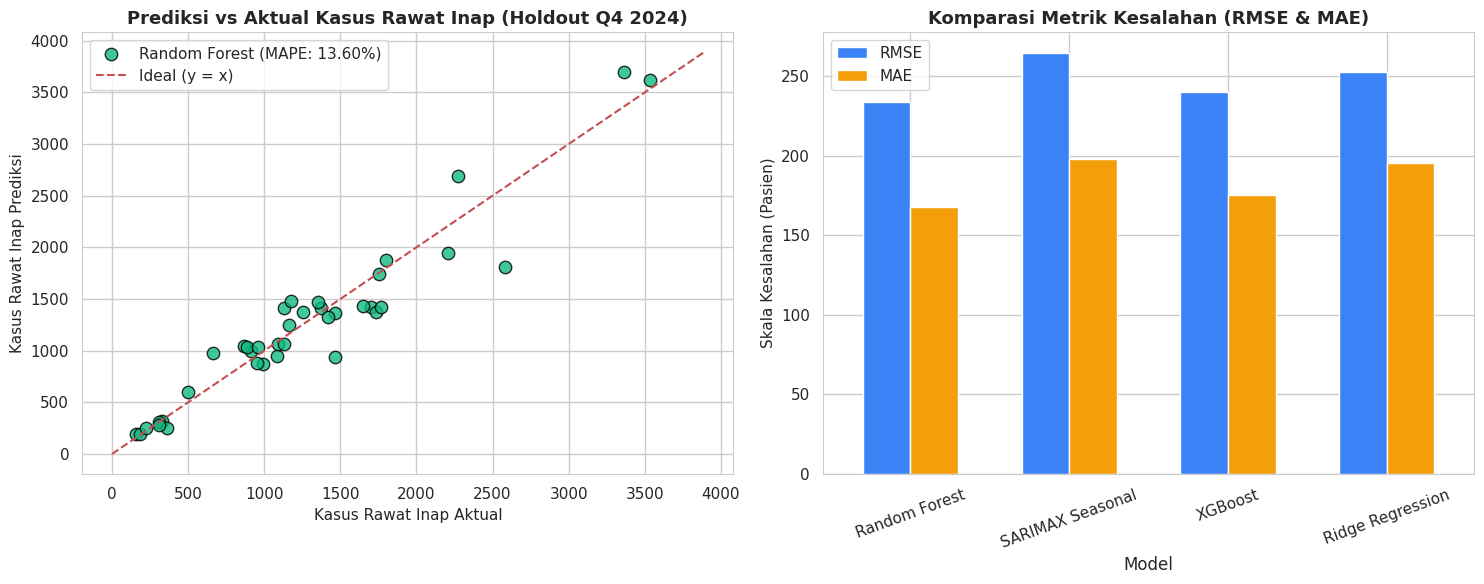

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Scatter Prediksi vs Aktual
ax[0].scatter(y_test, pred_rf, color='#10B981', s=80, alpha=0.8, edgecolors='black', label='Random Forest (MAPE: 13.60%)')
ax[0].plot([0, y_test.max()*1.1], [0, y_test.max()*1.1], 'r--', label='Ideal (y = x)')
ax[0].set_title('Prediksi vs Aktual Kasus Rawat Inap (Holdout Q4 2024)', fontsize=13, fontweight='bold')
ax[0].set_xlabel('Kasus Rawat Inap Aktual', fontsize=11)
ax[0].set_ylabel('Kasus Rawat Inap Prediksi', fontsize=11)
ax[0].legend(frameon=True)

# Plot 2: Perbandingan Metrik Evaluasi Model
eval_df.set_index('Model')[['RMSE', 'MAE']].plot(kind='bar', ax=ax[1], color=['#3B82F6', '#F59E0B'], width=0.6)
ax[1].set_title('Komparasi Metrik Kesalahan (RMSE & MAE)', fontsize=13, fontweight='bold')
ax[1].set_ylabel('Skala Kesalahan (Pasien)', fontsize=11)
ax[1].tick_params(axis='x', rotation=20)
ax[1].legend(frameon=True)

plt.tight_layout()
plt.show()

## 6. Proyeksi Deret Waktu Multi-Kuartal (2025–2026)
Kita memproyeksikan deret waktu 8 kuartal ke depan (2025-Q1 s.d. 2026-Q4) dengan mengintegrasikan laju pertumbuhan penduduk (CAGR) dan dinamika tren penyakit.

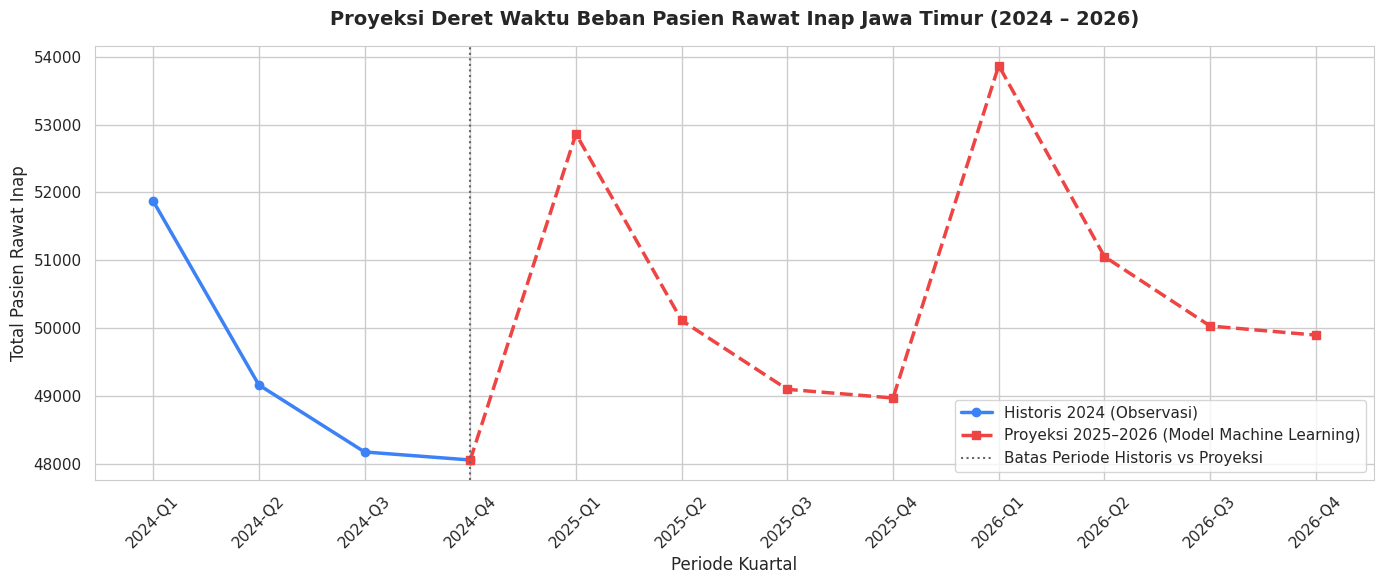

In [7]:
# Muat dataset proyeksi penuh hasil eksekusi pipeline
df_all_quarters = pd.read_csv('../data/morbidity_quarterly_forecast_2024_2026.csv')

# Agregasi tren historis dan proyeksi Jawa Timur per kuartal
jatim_timeline = df_all_quarters.groupby(['periode', 'tahun', 'triwulan', 'tipe_pelayanan', 'tipe_data'])['jumlah_pasien'].sum().reset_index()

plt.figure(figsize=(14, 6))
inap_time = jatim_timeline[jatim_timeline['tipe_pelayanan'] == 'rawat_inap']
hist_inap = inap_time[inap_time['tipe_data'] == 'Historis (Observasi)']
proj_inap = inap_time[inap_time['tipe_data'] == 'Proyeksi (Model ML)']

# Plot garis historis
plt.plot(hist_inap['periode'], hist_inap['jumlah_pasien'], marker='o', color='#3B82F6', linewidth=2.5, label='Historis 2024 (Observasi)')

# Plot garis proyeksi (terhubung dari titik terakhir 2024)
connect_line = pd.concat([hist_inap.tail(1), proj_inap])
plt.plot(connect_line['periode'], connect_line['jumlah_pasien'], marker='s', linestyle='--', color='#EF4444', linewidth=2.5, label='Proyeksi 2025–2026 (Model Machine Learning)')

plt.axvline(x='2024-Q4', color='#666666', linestyle=':', label='Batas Periode Historis vs Proyeksi')
plt.title('Proyeksi Deret Waktu Beban Pasien Rawat Inap Jawa Timur (2024 – 2026)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Periode Kuartal', fontsize=12)
plt.ylabel('Total Pasien Rawat Inap', fontsize=12)
plt.xticks(rotation=45)
plt.legend(frameon=True, fontsize=11)
plt.tight_layout()
plt.show()

## 7. Kalkulasi Kebutuhan Tempat Tidur (Bed Demand) 2026
Kita menerapkan formula standar Kemenkes RI & standar minimal WHO:
- **ALOS (Average Length of Stay)** = $4.5$ hari
- **Target BOR (Bed Occupancy Rate)** = $75\%$
- **Standar Minimal WHO** = $1.0$ Bed per $1.000$ penduduk

In [8]:
df_bed_forecast = pd.read_csv('../data/bed_demand_forecast_2026.csv')

print(f"Total Kabupaten/Kota Dianalisis: {len(df_bed_forecast)}")
df_bed_forecast[['nama_wilayah', 'total_tt', 'standar_tt_who_2026', 'kebutuhan_tt_komprehensif_2026', 'gap_tt_komprehensif', 'proyeksi_bor_persen_2026', 'status_kesiapsiagaan_2026']].head(10)

Total Kabupaten/Kota Dianalisis: 38


,nama_wilayah,total_tt,standar_tt_who_2026,kebutuhan_tt_komprehensif_2026,gap_tt_komprehensif,proyeksi_bor_persen_2026,status_kesiapsiagaan_2026
0,Kabupaten Pacitan,337,576,576,-239,8.52,Defisit Kritis (Merah)
1,Kabupaten Ponorogo,1139,903,903,236,4.68,Kapasitas Aman / Surplus (Hijau)
2,Kabupaten Trenggalek,674,723,723,-49,6.84,Waspada / Defisit Ringan (Kuning)
3,Kabupaten Tulungagung,2063,1081,1081,982,3.32,Kapasitas Aman / Surplus (Hijau)
4,Kabupaten Blitar,899,1206,1206,-307,8.14,Defisit Kritis (Merah)
5,Kabupaten Kediri,1343,1637,1637,-294,8.11,Defisit Kritis (Merah)
6,Kabupaten Malang,2945,2713,2713,232,4.85,Kapasitas Aman / Surplus (Hijau)
7,Kabupaten Lumajang,1081,1082,1082,-1,6.82,Waspada / Defisit Ringan (Kuning)
8,Kabupaten Jember,2139,2548,2548,-409,8.18,Defisit Kritis (Merah)
9,Kabupaten Banyuwangi,1538,1676,1676,-138,7.00,Waspada / Defisit Ringan (Kuning)


## 8. Visualisasi Kesiapsiagaan Tempat Tidur & Gap Kapasitas Wilayah 2026
Visualisasi komparasi kapasitas ranjang eksisting terhadap kebutuhan proyeksi 2026 untuk mengidentifikasi wilayah defisit kritis.

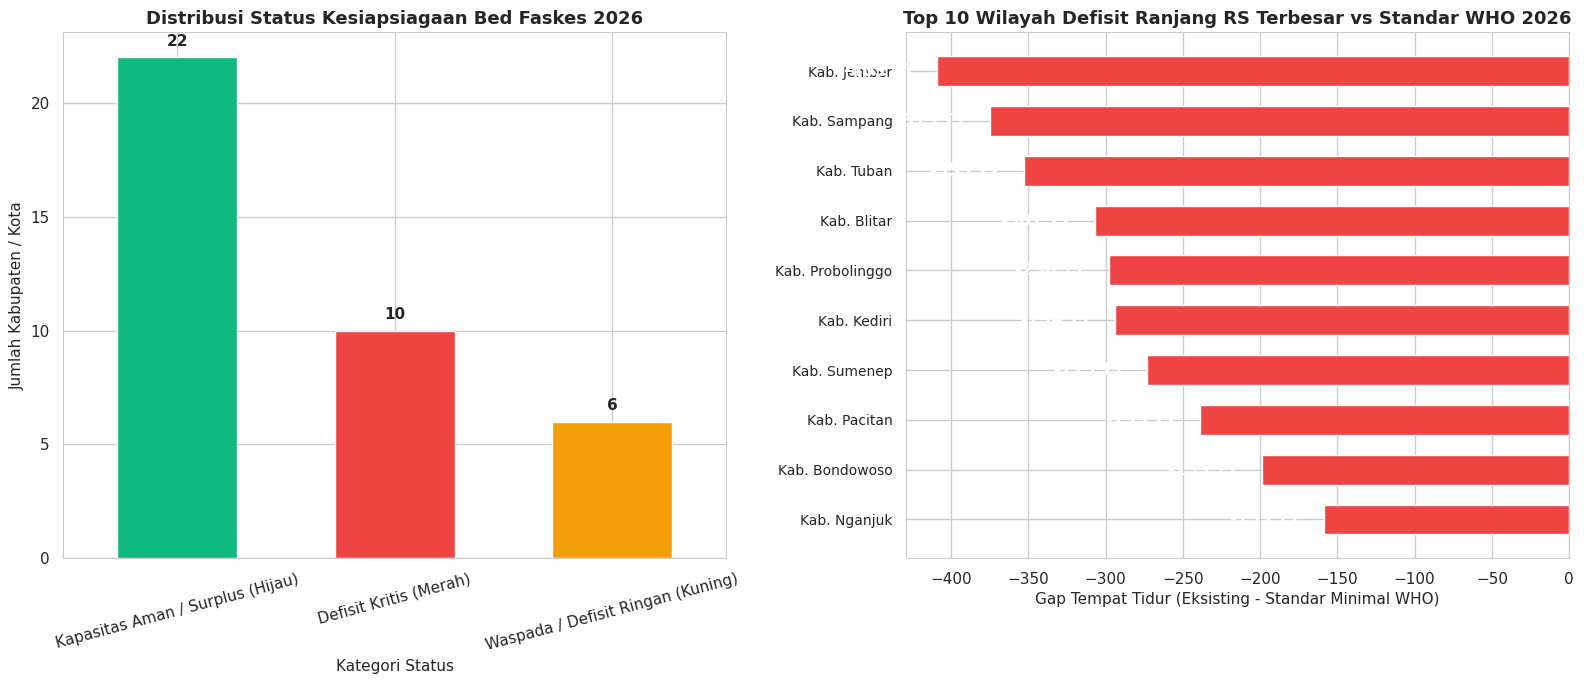

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: Distribusi Status Kesiapsiagaan Tempat Tidur 2026
status_counts = df_bed_forecast['status_kesiapsiagaan_2026'].value_counts()
colors = {'Kapasitas Aman / Surplus (Hijau)': '#10B981', 'Defisit Kritis (Merah)': '#EF4444', 'Waspada / Defisit Ringan (Kuning)': '#F59E0B'}
bar_colors = [colors.get(s, '#3B82F6') for s in status_counts.index]

status_counts.plot(kind='bar', ax=ax[0], color=bar_colors, width=0.55)
ax[0].set_title('Distribusi Status Kesiapsiagaan Bed Faskes 2026', fontsize=13, fontweight='bold')
ax[0].set_xlabel('Kategori Status', fontsize=11)
ax[0].set_ylabel('Jumlah Kabupaten / Kota', fontsize=11)
ax[0].tick_params(axis='x', rotation=15)

for i, v in enumerate(status_counts):
    ax[0].text(i, v + 0.5, str(v), ha='center', fontweight='bold', fontsize=11)

# Plot 2: Top 10 Wilayah dengan Defisit Tempat Tidur Terbesar
defisit_df = df_bed_forecast.sort_values('gap_tt_terhadap_who').head(10)
y_pos = np.arange(len(defisit_df))
ax[1].barh(y_pos, defisit_df['gap_tt_terhadap_who'], color='#EF4444', height=0.6)
ax[1].set_yticks(y_pos)
ax[1].set_yticklabels([w.replace('Kabupaten ', 'Kab. ').replace('Kota ', 'Kota ') for w in defisit_df['nama_wilayah']], fontsize=10)
ax[1].invert_yaxis()
ax[1].set_title('Top 10 Wilayah Defisit Ranjang RS Terbesar vs Standar WHO 2026', fontsize=13, fontweight='bold')
ax[1].set_xlabel('Gap Tempat Tidur (Eksisting - Standar Minimal WHO)', fontsize=11)

for i, v in enumerate(defisit_df['gap_tt_terhadap_who']):
    ax[1].text(v - 15, i, f"{v} TT", va='center', ha='right', fontweight='bold', color='white')

plt.tight_layout()
plt.show()

## 9. Tabel Ringkasan Rekomendasi Kebijakan Kapasitas Faskes 2026
Daftar rekomendasi intervensi strategis alokasi bed faskes untuk pelaporan manajerial Dinkes & Bappeda.

In [10]:
summary_display = df_bed_forecast[['nama_wilayah', 'total_tt', 'standar_tt_who_2026', 'gap_tt_terhadap_who', 'proyeksi_bor_persen_2026', 'status_kesiapsiagaan_2026', 'rekomendasi_kapasitas_2026']].head(12)
summary_display

,nama_wilayah,total_tt,standar_tt_who_2026,gap_tt_terhadap_who,proyeksi_bor_persen_2026,status_kesiapsiagaan_2026,rekomendasi_kapasitas_2026
0,Kabupaten Pacitan,337,576,-239,8.52,Defisit Kritis (Merah),Alokasi penambahan minimal 239 tempat tidur ba...
1,Kabupaten Ponorogo,1139,903,236,4.68,Kapasitas Aman / Surplus (Hijau),Pertahankan rasio bed optimal dan tingkatkan f...
2,Kabupaten Trenggalek,674,723,-49,6.84,Waspada / Defisit Ringan (Kuning),"Optimalisasi utilisasi bed existing, upgrade P..."
3,Kabupaten Tulungagung,2063,1081,982,3.32,Kapasitas Aman / Surplus (Hijau),Pertahankan rasio bed optimal dan tingkatkan f...
4,Kabupaten Blitar,899,1206,-307,8.14,Defisit Kritis (Merah),Alokasi penambahan minimal 307 tempat tidur ba...
5,Kabupaten Kediri,1343,1637,-294,8.11,Defisit Kritis (Merah),Alokasi penambahan minimal 294 tempat tidur ba...
6,Kabupaten Malang,2945,2713,232,4.85,Kapasitas Aman / Surplus (Hijau),Pertahankan rasio bed optimal dan tingkatkan f...
7,Kabupaten Lumajang,1081,1082,-1,6.82,Waspada / Defisit Ringan (Kuning),"Optimalisasi utilisasi bed existing, upgrade P..."
8,Kabupaten Jember,2139,2548,-409,8.18,Defisit Kritis (Merah),Alokasi penambahan minimal 409 tempat tidur ba...
9,Kabupaten Banyuwangi,1538,1676,-138,7.00,Waspada / Defisit Ringan (Kuning),"Optimalisasi utilisasi bed existing, upgrade P..."
